# Testbench for `conv1d_w13()`

In [13]:
#
# Copyright (C) 2024, Advanced Micro Devices, Inc. All rights reserved.
# SPDX-License-Identifier: MIT
#
# Author: Faisal El-Shabani

In [1]:
from tensorflow import keras
from tensorflow.keras.layers import Conv1D, MaxPooling1D
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import h5py as h5
import numpy as np
import os.path
import vfs
import varray as va

NITERATIONS = 4    # Number of AI Engine graph iterations

2025-08-15 08:14:22.926482: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-15 08:14:22.931276: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-15 08:14:22.940493: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755267262.954980 3240203 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755267262.959101 3240203 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755267262.971654 3240203 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Layer Definition

In [2]:
inputs = keras.Input(shape=(1024,2),name="input")
x1 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w1",activation='relu')(inputs)
x2 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w2")(x1)
x3 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w3",activation='relu')(x2)
x4 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w4")(x3)
x5 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w5",activation='relu')(x4)
x6 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w6")(x5)
x7 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w7",activation='relu')(x6)
x8 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w8")(x7)
x9 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w9",activation='relu')(x8)
x10 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w10")(x9)
x11 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w11",activation='relu')(x10)
outputs = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w12")(x11)

model_stim = keras.Model(inputs=inputs,outputs=outputs)
model_stim.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
w1_weights = np.loadtxt('../conv1d_w1/w1_weights_trained.txt')
w1_weights = (w1_weights.astype("bfloat16")).astype("float32")
w1_weights = np.reshape(w1_weights,(7,2,64))
w1_bias = np.loadtxt('../conv1d_w1/w1_bias_trained.txt')
w1_bias = (w1_bias.astype("bfloat16")).astype("float32")

w3_weights = np.loadtxt('../conv1d_template/w3_weights_trained.txt')
w3_weights = (w3_weights.astype("bfloat16")).astype("float32")
w3_weights = np.reshape(w3_weights,(7,64,64))
w3_bias = np.loadtxt('../conv1d_template/w3_bias_trained.txt')
w3_bias = (w3_bias.astype("bfloat16")).astype("float32")

w5_weights = np.loadtxt('../conv1d_template/w5_weights_trained.txt')
w5_weights = (w5_weights.astype("bfloat16")).astype("float32")
w5_weights = np.reshape(w5_weights,(7,64,64))
w5_bias = np.loadtxt('../conv1d_template/w5_bias_trained.txt')
w5_bias = (w5_bias.astype("bfloat16")).astype("float32")

w7_weights = np.loadtxt('../conv1d_template/w7_weights_trained.txt')
w7_weights = (w7_weights.astype("bfloat16")).astype("float32")
w7_weights = np.reshape(w7_weights,(7,64,64))
w7_bias = np.loadtxt('../conv1d_template/w7_bias_trained.txt')
w7_bias = (w7_bias.astype("bfloat16")).astype("float32")

w9_weights = np.loadtxt('../conv1d_template/w9_weights_trained.txt')
w9_weights = (w9_weights.astype("bfloat16")).astype("float32")
w9_weights = np.reshape(w9_weights,(7,64,64))
w9_bias = np.loadtxt('../conv1d_template/w9_bias_trained.txt')
w9_bias = (w9_bias.astype("bfloat16")).astype("float32")

w11_weights = np.loadtxt('../conv1d_template/w11_weights_trained.txt')
w11_weights = (w11_weights.astype("bfloat16")).astype("float32")
w11_weights = np.reshape(w11_weights,(7,64,64))
w11_bias = np.loadtxt('../conv1d_template/w11_bias_trained.txt')
w11_bias = (w11_bias.astype("bfloat16")).astype("float32")

model_stim.get_layer("conv1D_w1").set_weights((w1_weights,w1_bias))
model_stim.get_layer("conv1D_w3").set_weights((w3_weights,w3_bias))
model_stim.get_layer("conv1D_w5").set_weights((w5_weights,w5_bias))
model_stim.get_layer("conv1D_w7").set_weights((w7_weights,w7_bias))
model_stim.get_layer("conv1D_w9").set_weights((w9_weights,w9_bias))
model_stim.get_layer("conv1D_w11").set_weights((w11_weights,w11_bias))


2025-08-15 08:14:27.442605: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
model_stim.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1024, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w1 (Conv1D)              │ (None, 1024, 64)       │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w2 (MaxPooling1D)    │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w3 (Conv1D)              │ (None, 512, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w4 (MaxPooling1D)    │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w5 (Conv1D)              │ (None, 256, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w6 (MaxPooling1D)    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w7 (Conv1D)              │ (None, 128, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w8 (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w9 (Conv1D)              │ (None, 64, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w10 (MaxPooling1D)   │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w11 (Conv1D)             │ (None, 32, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w12 (MaxPooling1D)   │ (None, 16, 64)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,640 (565.00 KB)

 Trainable params: 144,640 (565.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
inputs = keras.Input(shape=(16,64),name="input_layer")
outputs = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w13",activation='relu')(inputs)
model = keras.Model(inputs=inputs,outputs=outputs)
w13_weights = np.loadtxt('w13_weights_trained.txt')
w13_weights = (w13_weights.astype("bfloat16")).astype("float32")
w13_weights = np.reshape(w13_weights,(7,64,64))
w13_bias = np.loadtxt('w13_bias_trained.txt')
w13_bias = (w13_bias.astype("bfloat16")).astype("float32")
model.set_weights((w13_weights,w13_bias))

In [5]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w13 (Conv1D)             │ (None, 16, 64)         │        28,736 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,736 (112.25 KB)

 Trainable params: 28,736 (112.25 KB)

 Non-trainable params: 0 (0.00 B)

### Read training and test data

In [ ]:
if not("RADIOML_DATA" in os.environ):
   print("Please set environment variable RADIOML_DATA to point to dataset found in https://www.kaggle.com/datasets/pinxau1000/radioml2018")
data_file = os.environ["RADIOML_DATA"] + 'GOLD_XYZ_OSC.0001_1024.hdf5'
file_handle = h5.File(data_file,'r')
myData = file_handle['X'][:]  #1024x2 samples 
myMods = file_handle['Y'][:]  #mods 
mySNRs = file_handle['Z'][:]  #snrs  
file_handle.close()
X_train ,X_predict ,Y_train ,Y_test, Z_train, Z_test =train_test_split(myData, myMods, mySNRs, test_size=0.2, random_state=0)
X_predict = X_predict[:NITERATIONS]
X_predict = (X_predict.astype("bfloat16")).astype("float32")
X_inputs = model_stim.predict(X_predict,batch_size=1024)
X_inputs = (X_inputs.astype("bfloat16")).astype("float32")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


## Compute Golden Outputs

In [7]:
predict = model.predict(X_inputs, batch_size=1024)
predict = (predict.astype("bfloat16")).astype("float32")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


## Store Layer Inputs

In [8]:
# Create directory if it doesn't exist
data_i = X_inputs
if not os.path.exists('data'):
    os.makedirs('data')
np.savetxt('data/data_i.txt',np.reshape(data_i,(-1,4)),fmt='%.12f %.12f %.12f %.12f')
print(X_inputs.shape)
print(data_i.shape)


(4, 16, 64)
(4, 16, 64)


## Store Layer Outputs

In [9]:
data_o = predict

np.savetxt('data/data_o.txt',np.reshape(data_o,(-1,4)),fmt='%.12f %.12f %.12f %.12f')
print(data_o.shape)

(4, 16, 64)


## Store Model weights and biases

In [10]:
print(w13_weights.shape)
print(w13_bias.shape)
weights = np.empty((7*64*64));
counter=0
for x in range(0,64,8):
    for y in range(0,64,8):
        for z in range(0,7):
            weights[counter*64:(counter+1)*64] = np.reshape(w13_weights[z,y:y+8,x:x+8],(-1))
            counter+=1
weights = np.reshape(weights,(-1,1))
np.savetxt('data/weights-rtp.txt',weights,fmt='%.12f')
print(weights.shape)

biases = np.reshape(w13_bias,(-1,1))
np.savetxt('data/biases-rtp.txt',biases,fmt='%.12f')
print(biases.shape)

(7, 64, 64)
(64,)
(28672, 1)
(64, 1)


## Run Vitis Functional Simulation

In [11]:
conv1d_w13_graph = vfs.aieGraph(
    input_file='conv1d_w13_app.cpp',
    part="xc2ve3858-ssva2112-2MP-e-S",
    include_paths=['./','../utility'])
act_o = conv1d_w13_graph.run(va.array(np.reshape(data_i,(-1,1)),dtype=va.bfloat16),va.array(weights,dtype=va.bfloat16),va.array(biases,dtype=va.bfloat16))
act_o = np.array(act_o)



Compiling AIE Graph
Compilation directory: /group/fndprod/faisale/repo/internal/designs/radio-ml/aie/conv1d_template/vfs_work/conv1d_w13_app_9247dd08
Compilation command: v++ -c --mode aie --config vfs_work/conv1d_w13_app_9247dd08/conv1d_w13_app.cfg --work_dir vfs_work/conv1d_w13_app_9247dd08/Work --output vfs_work/conv1d_w13_app_9247dd08/libadf.a --target x86sim
Writing log to: /group/fndprod/faisale/repo/internal/designs/radio-ml/aie/conv1d_template/vfs_work/conv1d_w13_app_9247dd08/Work/logs/aie_x86sim.log
Please wait ...

Compilation finished successfully.
Loaded AIEGraph


The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


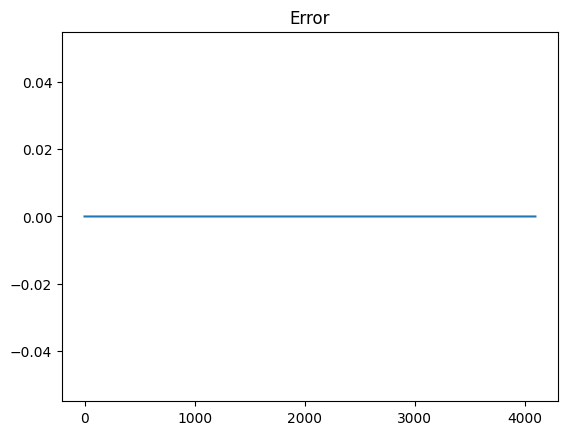

PASS: Max relative error 0.000000% is within tolerance 2.0%


In [12]:
data_o_reshaped = np.reshape(data_o,(-1))
err = data_o_reshaped-act_o
plt.plot(err)
plt.title("Error")
plt.show()

err_nonzero = err[data_o_reshaped!=0]
data_o_nonzero = data_o_reshaped[data_o_reshaped!=0]
relative_error_perc = np.abs(err_nonzero/data_o_nonzero * 100).max()
tolerance_perc      = 2.0  # 2 percent
if (relative_error_perc < tolerance_perc):
    print(f"PASS: Max relative error {relative_error_perc:.6f}% is within tolerance {tolerance_perc}%")
else:
    print(f"FAIL: Max relative error {relative_error_perc:.6f}% exceeds tolerance {tolerance_perc}%")